# BMW Sales Classification: Detecting Data Leakage in Machine Learning Models

## Project Overview

The objective of this project is to build a machine learning model capable of classifying BMW sales records into **High** and **Low** sales categories based on vehicle characteristics and sales-related attributes.

The analysis follows a complete machine learning workflow, including:

* Data acquisition and preprocessing
* Exploratory Data Analysis (EDA)
* Statistical analysis
* Feature engineering
* Model training and hyperparameter tuning
* Model evaluation and interpretation
* Data leakage investigation

During exploratory analysis, one feature (`Sales_Volume`) appeared to have an unusually strong relationship with the target variable. To assess its impact on model performance and validate model robustness, two modeling approaches were compared:

1. Models trained using all available features.
2. Models trained after removing the potentially leaking feature.

This comparison provides insight into how data leakage can inflate performance metrics and demonstrates the importance of validating feature influence before drawing conclusions from machine learning results.

---


In [1]:
# Required package for programmatic access to Kaggle datasets
%pip install kaggle

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries for data handling, visualization,
# statistical testing, preprocessing, model training, and evaluation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from kaggle.api.kaggle_api_extended import KaggleApi
from scipy.stats import chi2_contingency, zscore
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix, classification_report
)


---

## Data Loading and Overviewing

In [3]:
# Download and load the dataset directly from Kaggle
def load_kaggle_dataset(dataset, path):
    api = KaggleApi()
    api.authenticate()

    # Create local directory if it does not exist
    os.makedirs(path, exist_ok=True)

    # Download and extract dataset files
    api.dataset_download_files(dataset, path=path, unzip=True)

    # Locate the first CSV file in the downloaded dataset
    files = os.listdir(path)
    csv_files = [f for f in files if f.lower().endswith(".csv")]

    if not csv_files:
        raise FileNotFoundError("CSV files not found in the dataset!")

    csv_path = os.path.join(path, csv_files[0])
    print(f"Loading file → {csv_files[0]}")

    return pd.read_csv(csv_path)

# Define local storage path
path_to_data = "../data/bmw_sales"

# Load BMW sales dataset from Kaggle
df_bmw_sales = load_kaggle_dataset(
    "y0ussefkandil/bmw-sales2010-2024",
    path=path_to_data
)

Dataset URL: https://www.kaggle.com/datasets/y0ussefkandil/bmw-sales2010-2024
Loading file → BMW sales data (2010-2024).csv


In [5]:
df_bmw_sales.head(10)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
5,5 Series,2017,Middle East,Silver,Diesel,Manual,1.9,171362,42926,1232,Low
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High
7,M5,2014,Asia,Black,Diesel,Automatic,1.6,121156,102778,632,Low
8,X3,2016,South America,White,Diesel,Automatic,1.7,48073,116482,8944,High
9,i8,2019,Europe,White,Electric,Manual,3.0,35700,96257,4411,Low


In [6]:
df_bmw_sales.shape

(50000, 11)

In [7]:
df_bmw_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [8]:
df_bmw_sales.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [9]:
df_bmw_sales.nunique()

Model                      11
Year                       15
Region                      6
Color                       6
Fuel_Type                   4
Transmission                2
Engine_Size_L              36
Mileage_KM              44347
Price_USD               38246
Sales_Volume             9845
Sales_Classification        2
dtype: int64

In [10]:
df_bmw_sales.isna().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [11]:
df_bmw_sales.duplicated().sum()

0

---

## EDA (Exploratory Data Analysis)

In [12]:
# Define target variable and separate numerical and categorical features
target = 'Sales_Classification'

numeric_cols = df_bmw_sales.select_dtypes(exclude='object').columns

cat_cols = [
    col for col in df_bmw_sales.select_dtypes(include='object').columns
    if col != target
]

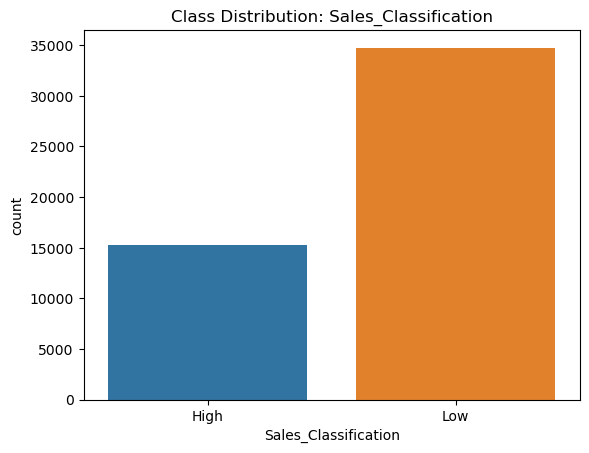

In [13]:
sns.countplot(x=target, data=df_bmw_sales)
plt.title(f'Class Distribution: {target}')
plt.show()

**Observation:**

The target distribution is imbalanced. To mitigate potential bias toward the majority class, `class_weight='balanced'` is used in the Random Forest classifier.

In [14]:
# Distribution of Categorical Features
for col in cat_cols:
    print(f"{col}:\n{df_bmw_sales[col].value_counts(normalize=True)}\n")

Model:
Model
7 Series    0.09332
i3          0.09236
i8          0.09212
3 Series    0.09190
5 Series    0.09184
X1          0.09140
X3          0.08994
X5          0.08974
M5          0.08956
X6          0.08956
M3          0.08826
Name: proportion, dtype: float64

Region:
Region
Asia             0.16908
Middle East      0.16746
North America    0.16670
Europe           0.16668
Africa           0.16506
South America    0.16502
Name: proportion, dtype: float64

Color:
Color
Red       0.16926
Silver    0.16700
Grey      0.16696
White     0.16608
Black     0.16546
Blue      0.16524
Name: proportion, dtype: float64

Fuel_Type:
Fuel_Type
Hybrid      0.25432
Petrol      0.25100
Electric    0.24942
Diesel      0.24526
Name: proportion, dtype: float64

Transmission:
Transmission
Manual       0.50308
Automatic    0.49692
Name: proportion, dtype: float64



**Observation:**

All categorical variables are approximately evenly distributed across their categories, with no dominant category observed.

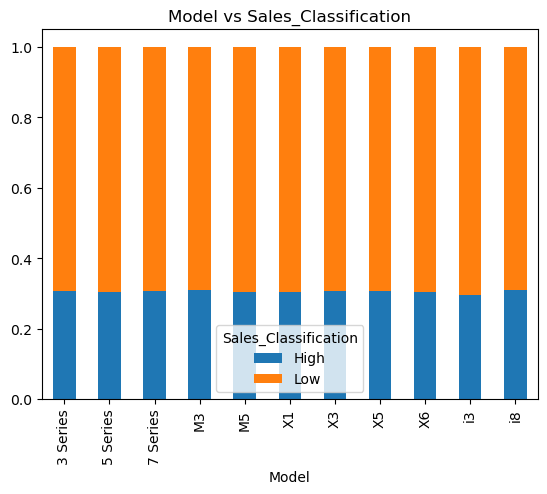

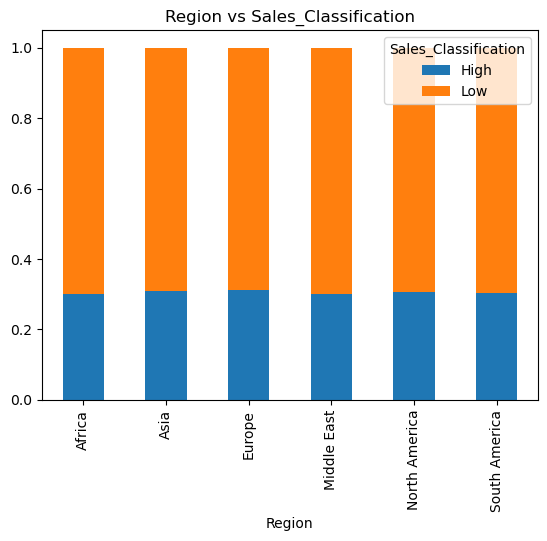

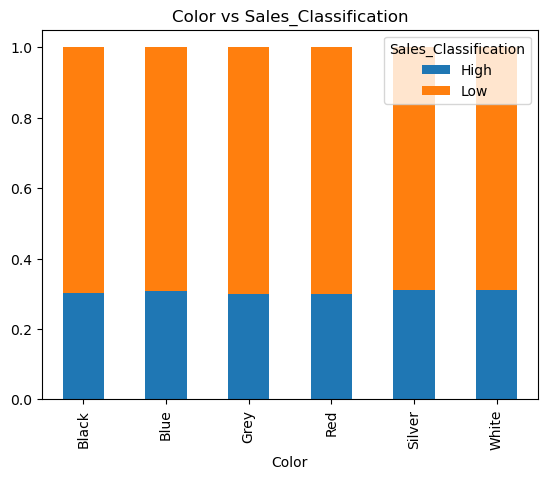

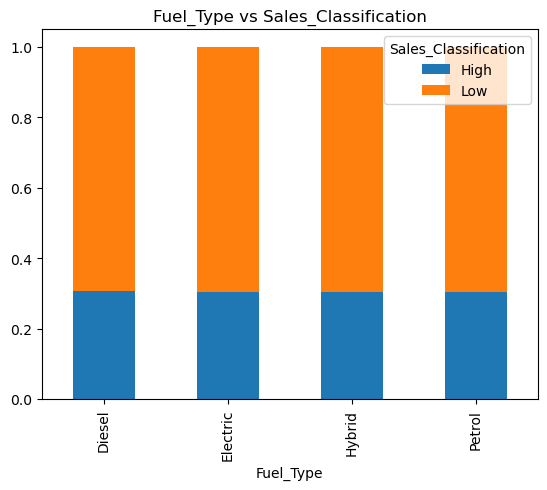

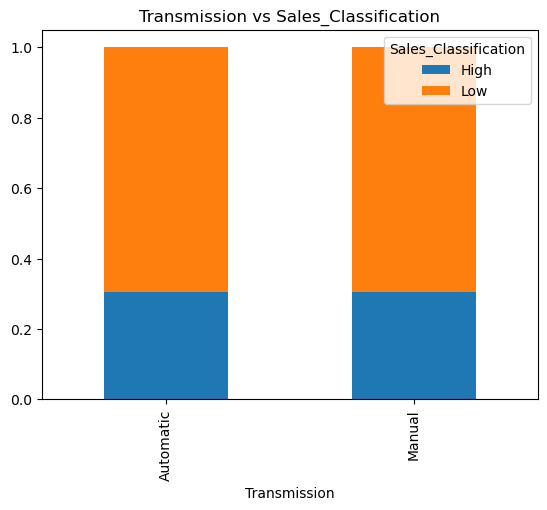

In [15]:
# Compare class proportions across categories
for col in cat_cols:
    cross = pd.crosstab(
        df_bmw_sales[col],
        df_bmw_sales['Sales_Classification'],
        normalize='index'
    )

    cross.plot(kind='bar', stacked=True)
    plt.title(f'{col} vs Sales_Classification')
    plt.show()

In [16]:
# Perform Chi-square tests to evaluate whether categorical features are associated with the target
for col in cat_cols:
    contingency = pd.crosstab(df_bmw_sales[col], df_bmw_sales[target])
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"{col}: p-value = {p}")

Model: p-value = 0.9714499333134624
Region: p-value = 0.281243202071958
Color: p-value = 0.22805849130478523
Fuel_Type: p-value = 0.9748465259933686
Transmission: p-value = 0.7198883487108411


**Observation:** 

All categorical variables show very similar class proportions across categories.
Chi-square tests produced high p-values (**> 0.05**), indicating no statistically significant association between these features and the target variable.

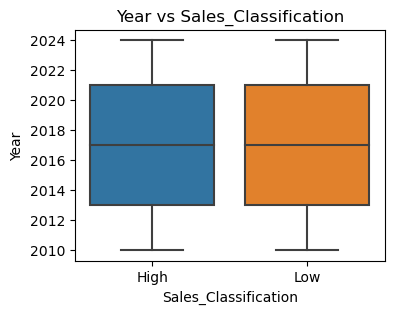

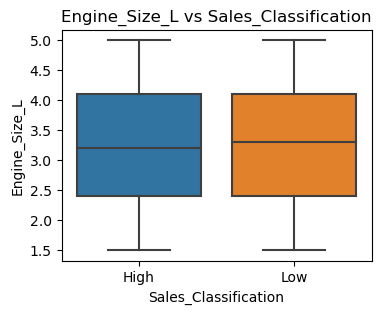

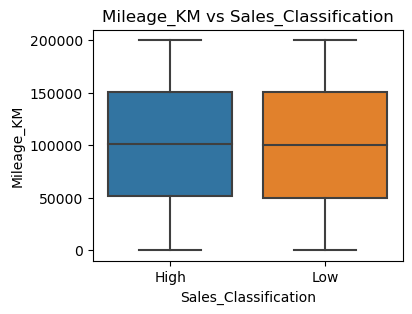

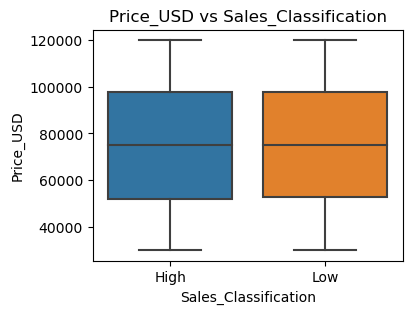

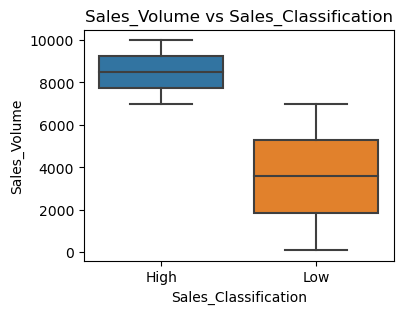

In [17]:
# Explore whether numerical features differ between High and Low sales classes
for col in numeric_cols:
    plt.figure(figsize=(4,3))
    sns.boxplot(x=target, y=col, data=df_bmw_sales)
    plt.title(f'{col} vs {target}')
    plt.show()


In [18]:
# Check whether Sales_Volume ranges overlap between target classes
df_bmw_sales.groupby('Sales_Classification')['Sales_Volume'].agg(['min', 'max'])

,min,max
Sales_Classification,,
High,7000,9999
Low,100,6999


**Observation:**

`Sales_Volume` perfectly separates the target classes.

>**Low: 100–6999**
>**High: 7000–9999**

This indicates that the target variable was likely derived directly from `Sales_Volume`, making it a clear source of target leakage.


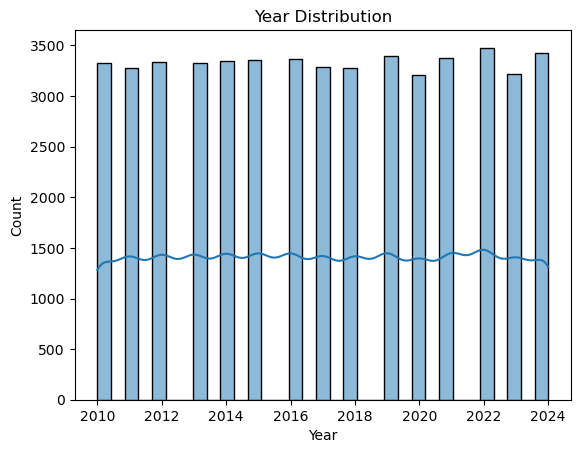

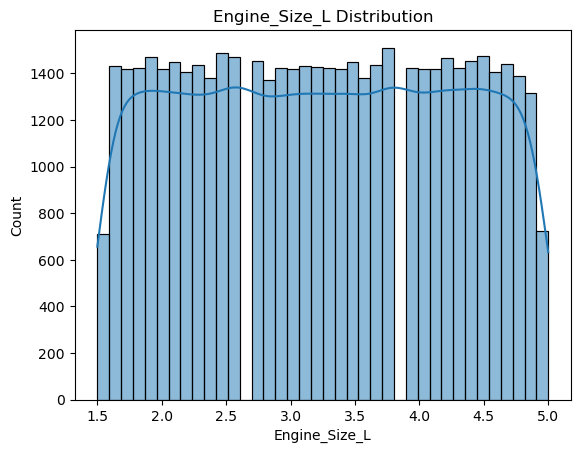

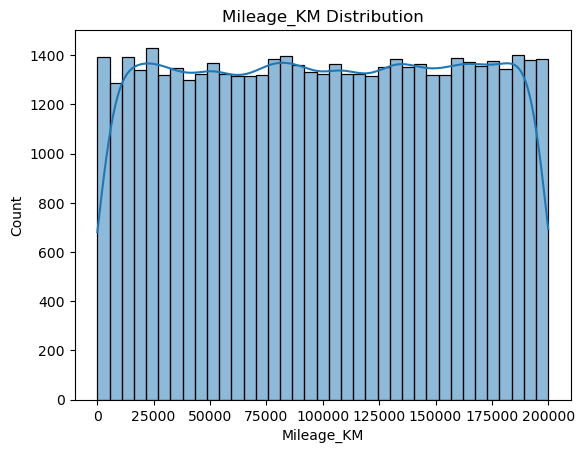

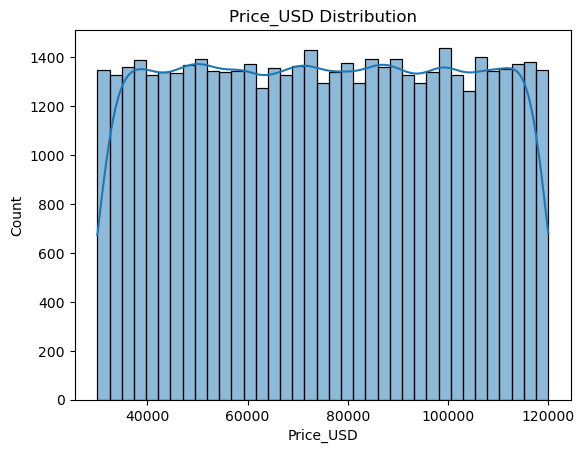

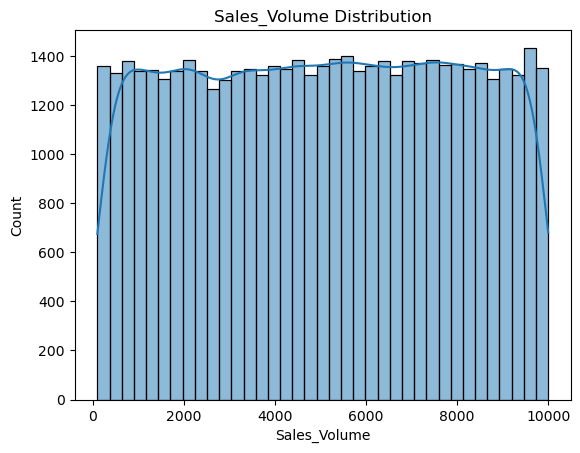

In [19]:
# Examine the distribution of numerical features
for col in numeric_cols:
    sns.histplot(df_bmw_sales[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

**Observation:**

Most numerical variables exhibit nearly uniform distributions.

This pattern suggests that the dataset may be synthetically generated rather than collected from real-world sales records.

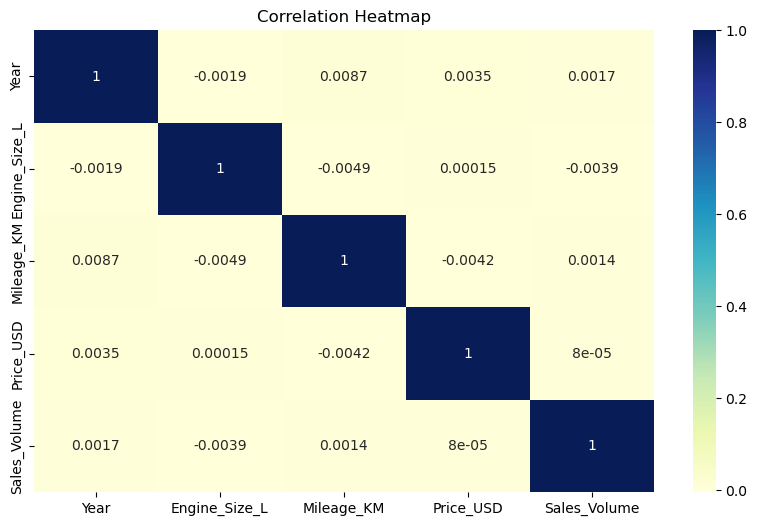

In [20]:
# Identify potential correlations and multicollinearity among numerical features
plt.figure(figsize=(10,6))
sns.heatmap(df_bmw_sales[numeric_cols].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

**Observation:**
    
No meaningful linear relationships are observed between numerical features.
All pairwise correlations are **close to zero**.

In [21]:
# Detect potential outliers using the Z-score method
for col in numeric_cols:
    z_scores = zscore(df_bmw_sales[col].dropna())
    outliers = sum(abs(z_scores) > 3)
    print(f'{col}: {outliers} potential outliers')

Year: 0 potential outliers
Engine_Size_L: 0 potential outliers
Mileage_KM: 0 potential outliers
Price_USD: 0 potential outliers
Sales_Volume: 0 potential outliers


**Observation:**

No potential outliers were detected in the numerical features using the **Z-score threshold of ±3**.

---

## Data Cleaning & Preprocessing

In [22]:
# Create a working copy of the dataset for feature engineering
df_model = df_bmw_sales.copy()

In [23]:
# Transform Year into a relative time feature
df_model['Years_Since_First_Sale'] = df_model['Year'] - df_model['Year'].min()

In [24]:
# Define target and features
X = df_model.drop(columns=['Sales_Classification', 'Year'])
y = df_model['Sales_Classification'].map({'Low': 0, 'High': 1})

In [25]:
# Define numerical and categorical features for preprocessing
numeric_features = [
    'Engine_Size_L',
    'Mileage_KM',
    'Price_USD',
    'Sales_Volume',
    'Years_Since_First_Sale'
]

categorical_features = [
    'Model',
    'Region',
    'Color',
    'Fuel_Type',
    'Transmission'
]

In [26]:
# Scale numerical features and encode categorical variables for model training
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

In [27]:
# Apply the appropriate preprocessing strategy to each feature type
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [28]:
# Split the data into training and test sets while preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---

## Modeling

In [29]:
# Baseline Random Forest model using all available features
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [30]:
# Train the baseline Random Forest model using all available features
baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Engine_Size_L',
                                                   'Mileage_KM', 'Price_USD',
                                                   'Sales_Volume',
                                                   'Years_Since_First_Sale']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Model', 'Region', 'Color',
                                                   'Fuel_Type',
                                                   'Transmission'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [31]:
# Evaluate the trained model on unseen data
y_pred_baseline = baseline_pipeline.predict(X_test)

In [32]:
# Define the hyperparameter search space for Random Forest tuning
param_grid = {
    'clf__n_estimators':[100,200],
    'clf__max_depth':[None,10,20],
    'clf__min_samples_split':[2,5],
    'clf__min_samples_leaf':[1,2],
}

In [33]:
# Random Forest pipeline for hyperparameter tuning
grid_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [34]:
# Search for the best hyperparameter combination using cross-validation
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [35]:
# Run hyperparameter tuning on the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Engine_Size_L',
                                                                          'Mileage_KM',
                                                                          'Price_USD',
                                                                          'Sales_Volume',
                                                                          'Years_Since_First_Sale']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Model',
                                                                          'Region',
                                                                          'Color',
                                                                          'Fuel_Type',
                                                                          'Transmission'])])),
                                       ('clf',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_depth': [None, 10, 20],
                         'clf__min_samples_leaf': [1, 2],
                         'clf__min_samples_split': [2, 5],
                         'clf__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=2)

In [36]:
# Generate predictions using the best model found by GridSearchCV
y_pred_grid = grid_search.predict(X_test)

---

## Model Evaluation

In [37]:
# Extract baseline model hyperparameters for comparison
param_keys = ['max_depth', 'min_samples_leaf', 'min_samples_split', 'n_estimators']

baseline_params = {
    key: baseline_pipeline.named_steps['clf'].get_params()[key]
    for key in param_keys
}

In [38]:
# Compare baseline and tuned hyperparameters
print("Baseline Model Parameters:", baseline_params)
print("Best GridSearch Parameters:", grid_search.best_params_)

Baseline Model Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GridSearch Parameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}


In [39]:
# Calculate evaluation metrics for the baseline model
baseline_metrics = {
    'Model': 'Baseline',
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'ROC AUC': roc_auc_score(y_test, y_pred_baseline),
    'F1': f1_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline),
    'Recall': recall_score(y_test, y_pred_baseline)
}

In [40]:
# Calculate evaluation metrics for the tuned model
grid_metrics = {
    'Model': 'GridSearch',
    'Accuracy': accuracy_score(y_test, y_pred_grid),
    'ROC AUC': roc_auc_score(y_test, y_pred_grid),
    'F1': f1_score(y_test, y_pred_grid),
    'Precision': precision_score(y_test, y_pred_grid),
    'Recall': recall_score(y_test, y_pred_grid)
}

In [41]:
# Compare performance metrics of the baseline and tuned models
metrics_df = pd.DataFrame([baseline_metrics, grid_metrics])
metrics_df

,Model,Accuracy,ROC AUC,F1,Precision,Recall
0,Baseline,1.0,1.0,1.0,1.0,1.0
1,GridSearch,1.0,1.0,1.0,1.0,1.0


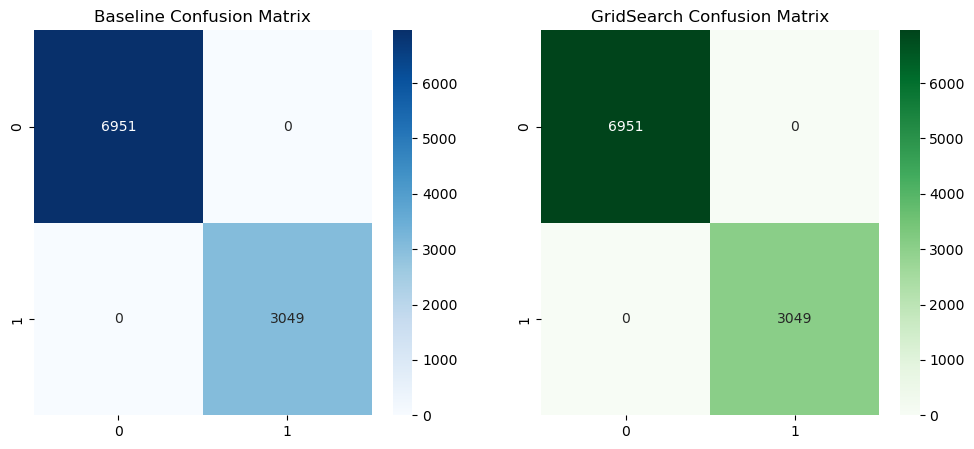

In [42]:
# Compare classification performance using confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_baseline),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Baseline Confusion Matrix')

sns.heatmap(
    confusion_matrix(y_test, y_pred_grid),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title('GridSearch Confusion Matrix')

plt.show()

**Observation:**

Both baseline and tuned Random Forest models achieved perfect metrics (**Accuracy, ROC AUC, F1 = 1.0**).  
Such performance is highly unusual and suggests possible **data leakage** or the presence of a dominant feature  
that directly determines the target variable.  

To confirm this, we will review the results of the GridSearchCV parameter combinations  
to check whether all configurations yield the same performance.


In [43]:
# Review GridSearchCV results to understand the impact of different hyperparameter settings
print("Total combinations tested:", len(grid_search.cv_results_['params']))
print("ROC AUC for each combination:")
for mean, params in zip(grid_search.cv_results_['mean_test_score'], grid_search.cv_results_['params']):
    print(f"{mean:.4f} -> {params}")

Total combinations tested: 24
ROC AUC for each combination:
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
1.0000 -> {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 2

---

## Feature Importance Analysis

In [44]:
# Retrieve the best-performing model for feature importance analysis
best_pipeline = grid_search.best_estimator_

In [45]:
# Extract transformed feature names for feature importance analysis
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [46]:
# Extract feature importance scores from the trained Random Forest model
importances = best_pipeline.named_steps['clf'].feature_importances_

In [47]:
# Combine feature names and importance scores for interpretation
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

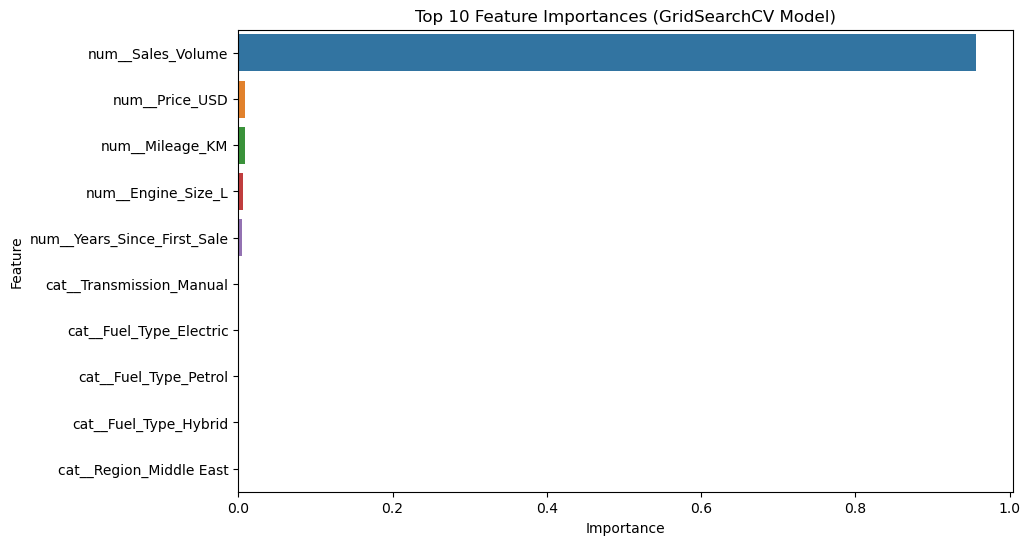

In [48]:
# Visualize the most important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title('Top 10 Feature Importances (GridSearchCV Model)')
plt.show()

**Observation:**

Feature importance analysis shows that `Sales_Volume` overwhelmingly dominates the model,  
accounting for nearly all predictive power. This confirms earlier EDA findings,  
where `Sales_Volume` perfectly separated the target classes.  

Such dominance strongly suggests **data leakage**, as the target variable (`Sales_Classification`)  
was likely derived from this feature.  

**Next step:**  
    
Rebuild the model **without `Sales_Volume`** to verify whether the model can still generalize  
and learn meaningful patterns from the remaining features.

---

## Model Refinement (Without `Sales_Volume`)

In [49]:
# Remove Sales_Volume to test the target leakage hypothesis
X_refined = X.drop(columns=['Sales_Volume'])

In [50]:
# Split the refined dataset into training and test sets
X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(
    X_refined, y, test_size=0.2, random_state=42, stratify=y
)

In [51]:
# Define feature groups after removing the suspected leakage feature
numeric_features_refined = [
    'Engine_Size_L',
    'Mileage_KM',
    'Price_USD',
    'Years_Since_First_Sale'
]

categorical_features_refined = [
    'Model',
    'Region',
    'Color',
    'Fuel_Type',
    'Transmission'
]

In [52]:
# Apply preprocessing to the refined feature set
preprocessor_refined = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_refined),
        ('cat', categorical_transformer, categorical_features_refined)
    ]
)

In [53]:
# Baseline model after removing the leakage feature
baseline_pipeline_refined = Pipeline([
    ('preprocessor', preprocessor_refined),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [54]:
# Train the baseline model without the leakage feature
baseline_pipeline_refined.fit(X_train_ref, y_train_ref)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Engine_Size_L',
                                                   'Mileage_KM', 'Price_USD',
                                                   'Years_Since_First_Sale']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Model', 'Region', 'Color',
                                                   'Fuel_Type',
                                                   'Transmission'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [55]:
# Generate predictions using the leakage-free model
y_pred_baseline_ref = baseline_pipeline_refined.predict(X_test_ref)

In [56]:
# Pipeline for hyperparameter tuning without the leakage feature
grid_pipeline_refined = Pipeline([
    ('preprocessor', preprocessor_refined),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])


In [57]:
# Optimize hyperparameters for the leakage-free model using cross-validation
grid_search_refined = GridSearchCV(
    estimator=grid_pipeline_refined,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [58]:
# Run hyperparameter tuning on the refined training data
grid_search_refined.fit(X_train_ref, y_train_ref)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Engine_Size_L',
                                                                          'Mileage_KM',
                                                                          'Price_USD',
                                                                          'Years_Since_First_Sale']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Model',
                                                                          'Region',
                                                                          'Color',
                                                                          'Fuel_Type',
                                                                          'Transmission'])])),
                                       ('clf',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_depth': [None, 10, 20],
                         'clf__min_samples_leaf': [1, 2],
                         'clf__min_samples_split': [2, 5],
                         'clf__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=2)

In [59]:
# Generate predictions using the tuned leakage-free model
y_pred_grid_ref = grid_search_refined.predict(X_test_ref)

---

## Model Evaluation (Without `Sales_Volume`)


In [60]:
# Extract hyperparameters from the refined baseline model
baseline_params_ref = {
    key: baseline_pipeline_refined.named_steps['clf'].get_params()[key]
    for key in param_keys
}

In [61]:
# Compare hyperparameters of the refined baseline and tuned models
print("Refined Baseline Model Parameters:", baseline_params_ref)
print("Best Refined GridSearch Parameters:", grid_search_refined.best_params_)

Refined Baseline Model Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Refined GridSearch Parameters: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}


In [62]:
# Calculate evaluation metrics for the refined baseline model
baseline_metrics_ref = {
    'Model': 'Refined Baseline',
    'Accuracy': accuracy_score(y_test_ref, y_pred_baseline_ref),
    'ROC AUC': roc_auc_score(y_test_ref, y_pred_baseline_ref),
    'F1': f1_score(y_test_ref, y_pred_baseline_ref),
    'Precision': precision_score(y_test_ref, y_pred_baseline_ref),
    'Recall': recall_score(y_test_ref, y_pred_baseline_ref)
}

In [65]:
# Calculate evaluation metrics for the refined tuned model
grid_metrics_ref = {
    'Model': 'Refined GridSearch',
    'Accuracy': accuracy_score(y_test_ref, y_pred_grid_ref),
    'ROC AUC': roc_auc_score(y_test_ref, y_pred_grid_ref),
    'F1': f1_score(y_test_ref, y_pred_grid_ref),
    'Precision': precision_score(y_test_ref, y_pred_grid_ref),
    'Recall': recall_score(y_test_ref, y_pred_grid_ref)
}

In [66]:
# Compare performance across original and leakage-free models
metrics_df_refined = pd.DataFrame([
    baseline_metrics,
    grid_metrics,
    baseline_metrics_ref,
    grid_metrics_ref
])

metrics_df_refined

,Model,Accuracy,ROC AUC,F1,Precision,Recall
0,Baseline,1.0000,1.000000,1.000000,1.000000,1.000000
1,GridSearch,1.0000,1.000000,1.000000,1.000000,1.000000
2,Refined Baseline,0.6899,0.500034,0.025762,0.305970,0.013447
3,Refined GridSearch,0.5850,0.494540,0.278512,0.296337,0.262709


**Observation:**

After removing `Sales_Volume`, the model performance dropped dramatically.
This confirms that `Sales_Volume` was overwhelmingly driving predictions and likely introduced **data leakage**.  
The model without this feature shows that the remaining variables alone are not sufficient for accurate classification,  
highlighting the importance of careful feature selection and validation.


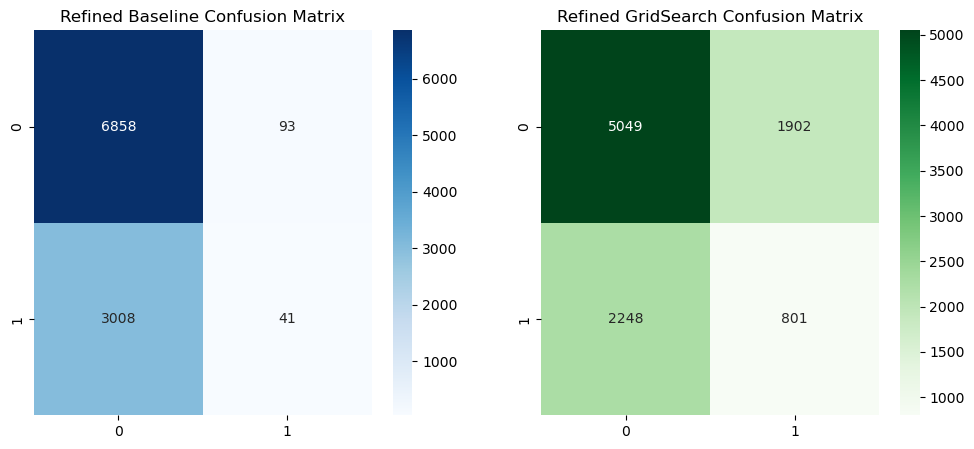

In [67]:
# Compare classification performance of the leakage-free models
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test_ref, y_pred_baseline_ref),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Refined Baseline Confusion Matrix')

sns.heatmap(
    confusion_matrix(y_test_ref, y_pred_grid_ref),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title('Refined GridSearch Confusion Matrix')

plt.show()

**Observation:**

After removing `Sales_Volume`, both models show a substantial decline in classification performance.

The Refined Baseline model correctly identifies most Low-sales observations but fails to recognize the majority of High-sales cases, resulting in a large number of false negatives.

The Refined GridSearch model improves the detection of High-sales cases compared to the baseline model, but this improvement comes at the cost of a large increase in false positives.

Overall, neither model achieves a satisfactory balance between identifying High-sales and Low-sales observations, indicating that the remaining features contain limited predictive information.

---

## Refined Feature Importance

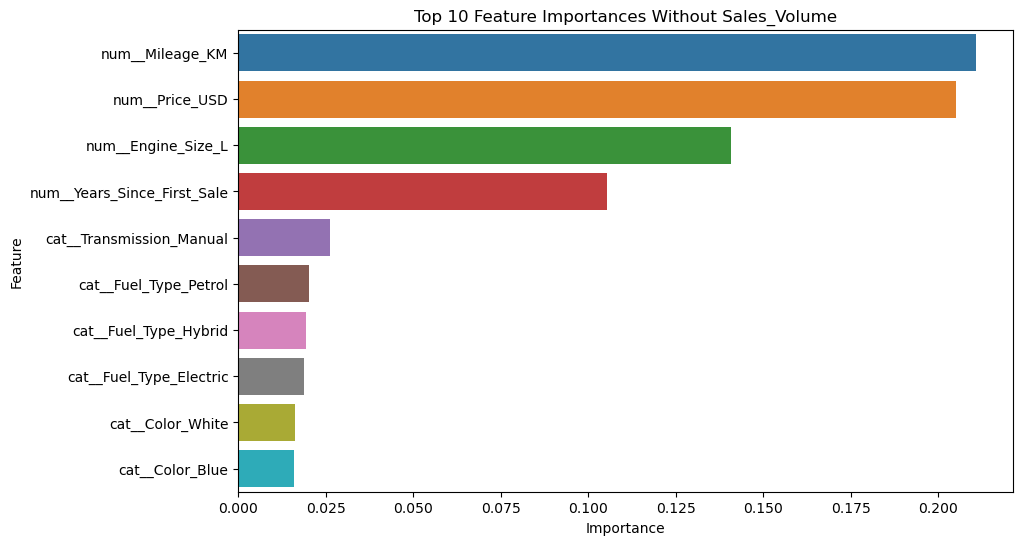

In [69]:
# Analyze feature importance after removing the leakage feature

best_pipeline_refined = grid_search_refined.best_estimator_

feature_names_refined = best_pipeline_refined.named_steps['preprocessor'].get_feature_names_out()
importances_refined = best_pipeline_refined.named_steps['clf'].feature_importances_

feat_imp_refined = pd.DataFrame({
    'Feature': feature_names_refined,
    'Importance': importances_refined
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_refined.head(10))
plt.title('Top 10 Feature Importances Without Sales_Volume')
plt.show()

**Observation:**

After removing `Sales_Volume`, feature importance becomes more evenly distributed across multiple numerical variables.

`Mileage_KM` and `Price_USD` emerge as the most influential predictors, followed by `Engine_Size_L` and `Years_Since_First_Sale`. However, no remaining feature demonstrates the overwhelming dominance previously observed for Sales_Volume.

This result supports the earlier hypothesis that `Sales_Volume` was driving most of the model's predictive power.

---

## Conclusions

1. **Data Overview & EDA**

   * The target variable showed a moderate class imbalance (approximately **70% Low** vs **30% High**).
   * Exploratory analysis suggested that `Sales_Volume` strongly separates the two target classes, raising concerns about potential data leakage.

2. **Modeling with Sales_Volume**

   * Both the baseline Random Forest and the GridSearch-optimized model achieved near-perfect classification performance.
   * Feature importance analysis revealed that `Sales_Volume` overwhelmingly dominated all other predictors and accounted for almost all predictive power.

3. **Modeling without Sales_Volume**

   * After removing `Sales_Volume`, model performance dropped substantially, with **ROC AUC approaching 0.5**, indicating little predictive capability.
   * Confusion matrices showed a significant decline in the model's ability to correctly identify the positive class.
   * Feature importance became more evenly distributed across variables such as `Mileage_KM`, `Price_USD`, `Engine_Size_L`, and `Years_Since_First_Sale`, but none provided sufficient predictive signal on their own.

4. **Key Takeaways**

   * This analysis highlights the importance of performing thorough exploratory data analysis and checking for potential data leakage before interpreting model performance.
   * A single dominant feature can create the illusion of a highly accurate model while masking the limited predictive value of the remaining variables.
   * Feature importance analysis and feature-removal experiments are effective techniques for validating model robustness.
   * The dataset appears to be synthetically generated, as most numerical variables follow nearly uniform distributions, exhibit almost zero correlation, and contain no meaningful outliers.
